#  Credit Risk: Exploratory Data Analysis

**Author:** Sunmi  
**Dataset:** Credit Risk (32,416 customers)  
**Goal:** To understand the key drivers of loan default and identify patterns that distinguish high risk borrowers from low risk borrower.

**Tools:** Python · Pandas · Matplotlib · Seaborn

The dataset contains demographic, financial, and credit history variables including income, loan amount, employment duration, and credit history, with a binary target variable indicating loan default status.


## Table of Contents
1. [Setup & Data Loading](#1)
2. [Dataset Overview](#2)
3. [Target Variable Analysis](#3)
4. [Univariate Analysis(Numerical Features)](#4)
5. [Unvariate Analysis(Categorical Features)](#5)
6. [Correlation Analysis](#6)
7. [Bivariate Analysis:Features vs Defaults](#7)
8. [Outlier Investigation](#8)
9. [EDA Summary & Key Findings](#9)


## 1. Setup & Data Loading <a id='1'></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ── Global plot styling ────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'xtick.labelsize': 9,
                     'ytick.labelsize': 9})

In [2]:
df=pd.read_csv(r"c:\Users\HP USER\Desktop\Credit Risk Full Project\Credit_Risk_Dataset_Cleaned.csv")

In [3]:
df.shape

(32416, 12)

In [4]:
df.head()

,Age,Income,Home_Ownership,Employment_Years,Loan_Purpose,Loan_Risk_Grade,Loan_Amount,Interest_Rate,Loan_Default_Status,Loan_Income_Ratio,Previous_Default,Credit_History_Years
0,22,59000,RENT,123,PERSONAL,D,35000,16.02,1,0.59,Yes,3
1,21,9600,OWN,5,EDUCATION,B,1000,11.14,0,0.10,No,2
2,25,9600,MORTGAGE,1,MEDICAL,C,5500,12.87,1,0.57,No,3
3,23,65500,RENT,4,MEDICAL,C,35000,15.23,1,0.53,No,2
4,24,54400,RENT,8,MEDICAL,C,35000,14.27,1,0.55,Yes,4


## 2. Dataset Overview <a id='2'></a>

The dataset contains **32,416 bank customers** with 12 features.
The target variable is `Previous_Default`, whether a customer will default payment or not.


In [5]:
# Data types
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Basic Statistics ===")
df.describe().round(2)

=== Data Types ===
Age                       int64
Income                    int64
Home_Ownership           object
Employment_Years          int64
Loan_Purpose             object
Loan_Risk_Grade          object
Loan_Amount               int64
Interest_Rate           float64
Loan_Default_Status       int64
Loan_Income_Ratio       float64
Previous_Default         object
Credit_History_Years      int64
dtype: object

=== Basic Statistics ===


,Age,Income,Employment_Years,Loan_Amount,Interest_Rate,Loan_Default_Status,Loan_Income_Ratio,Credit_History_Years
count,32416.00,32416.00,32416.00,32416.00,32416.00,32416.00,32416.00,32416.00
mean,27.75,66091.64,4.77,9593.85,11.01,0.22,0.17,5.81
std,6.35,62015.58,4.09,6322.73,3.08,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38542.00,2.00,5000.00,8.49,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79218.00,7.00,12250.00,13.11,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


In [6]:
# Confirm no missing values after cleaning
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else " No missing values, dataset is clean!")

print(f"\n=== Duplicate Rows ===")
print(f"Duplicates: {df.duplicated().sum()}  None found")

=== Missing Values ===


 No missing values, dataset is clean!

=== Duplicate Rows ===
Duplicates: 0  None found


## 3. Target Variable Analysis <a id='3'></a>

Before exploring features, we need to understand the **Loan_Default_Status** which is our target variable.
0 = did not default
1 = defaulted

In [7]:
default_counts = df['Loan_Default_Status'].value_counts()
default_pct    = df['Loan_Default_Status'].value_counts(normalize=True) * 100

print("=== Default Distribution ===")
print(f"did not default (0): {default_counts[0]:,}  ({default_pct[0]:.1f}%)")
print(f"defaulted  (1): {default_counts[1]:,}  ({default_pct[1]:.1f}%)")

=== Default Distribution ===
did not default (0): 25,327  (78.1%)
defaulted  (1): 7,089  (21.9%)


Class imbalance ratio: 3.6:1

   The dataset exhibits a moderate class imbalance, where non-default cases account for 78.1% of observations while default cases account for 21.9%. This means we have ~4 non-defaulters for every 1 person that defaulted.


## 4. Univariate Analysis(Numerical Features) <a id='4'></a>

We examine each feature independently to understand its distribution.

── Descriptive Statistics (Numerical Features) ──


,Age,Income,Employment_Years,Loan_Amount,Interest_Rate,Loan_Income_Ratio,Credit_History_Years
count,32416.00,32416.00,32416.00,32416.00,32416.00,32416.00,32416.00
mean,27.75,66091.64,4.77,9593.85,11.01,0.17,5.81
std,6.35,62015.58,4.09,6322.73,3.08,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,2.00
25%,23.00,38542.00,2.00,5000.00,8.49,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.15,4.00
75%,30.00,79218.00,7.00,12250.00,13.11,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,0.83,30.00


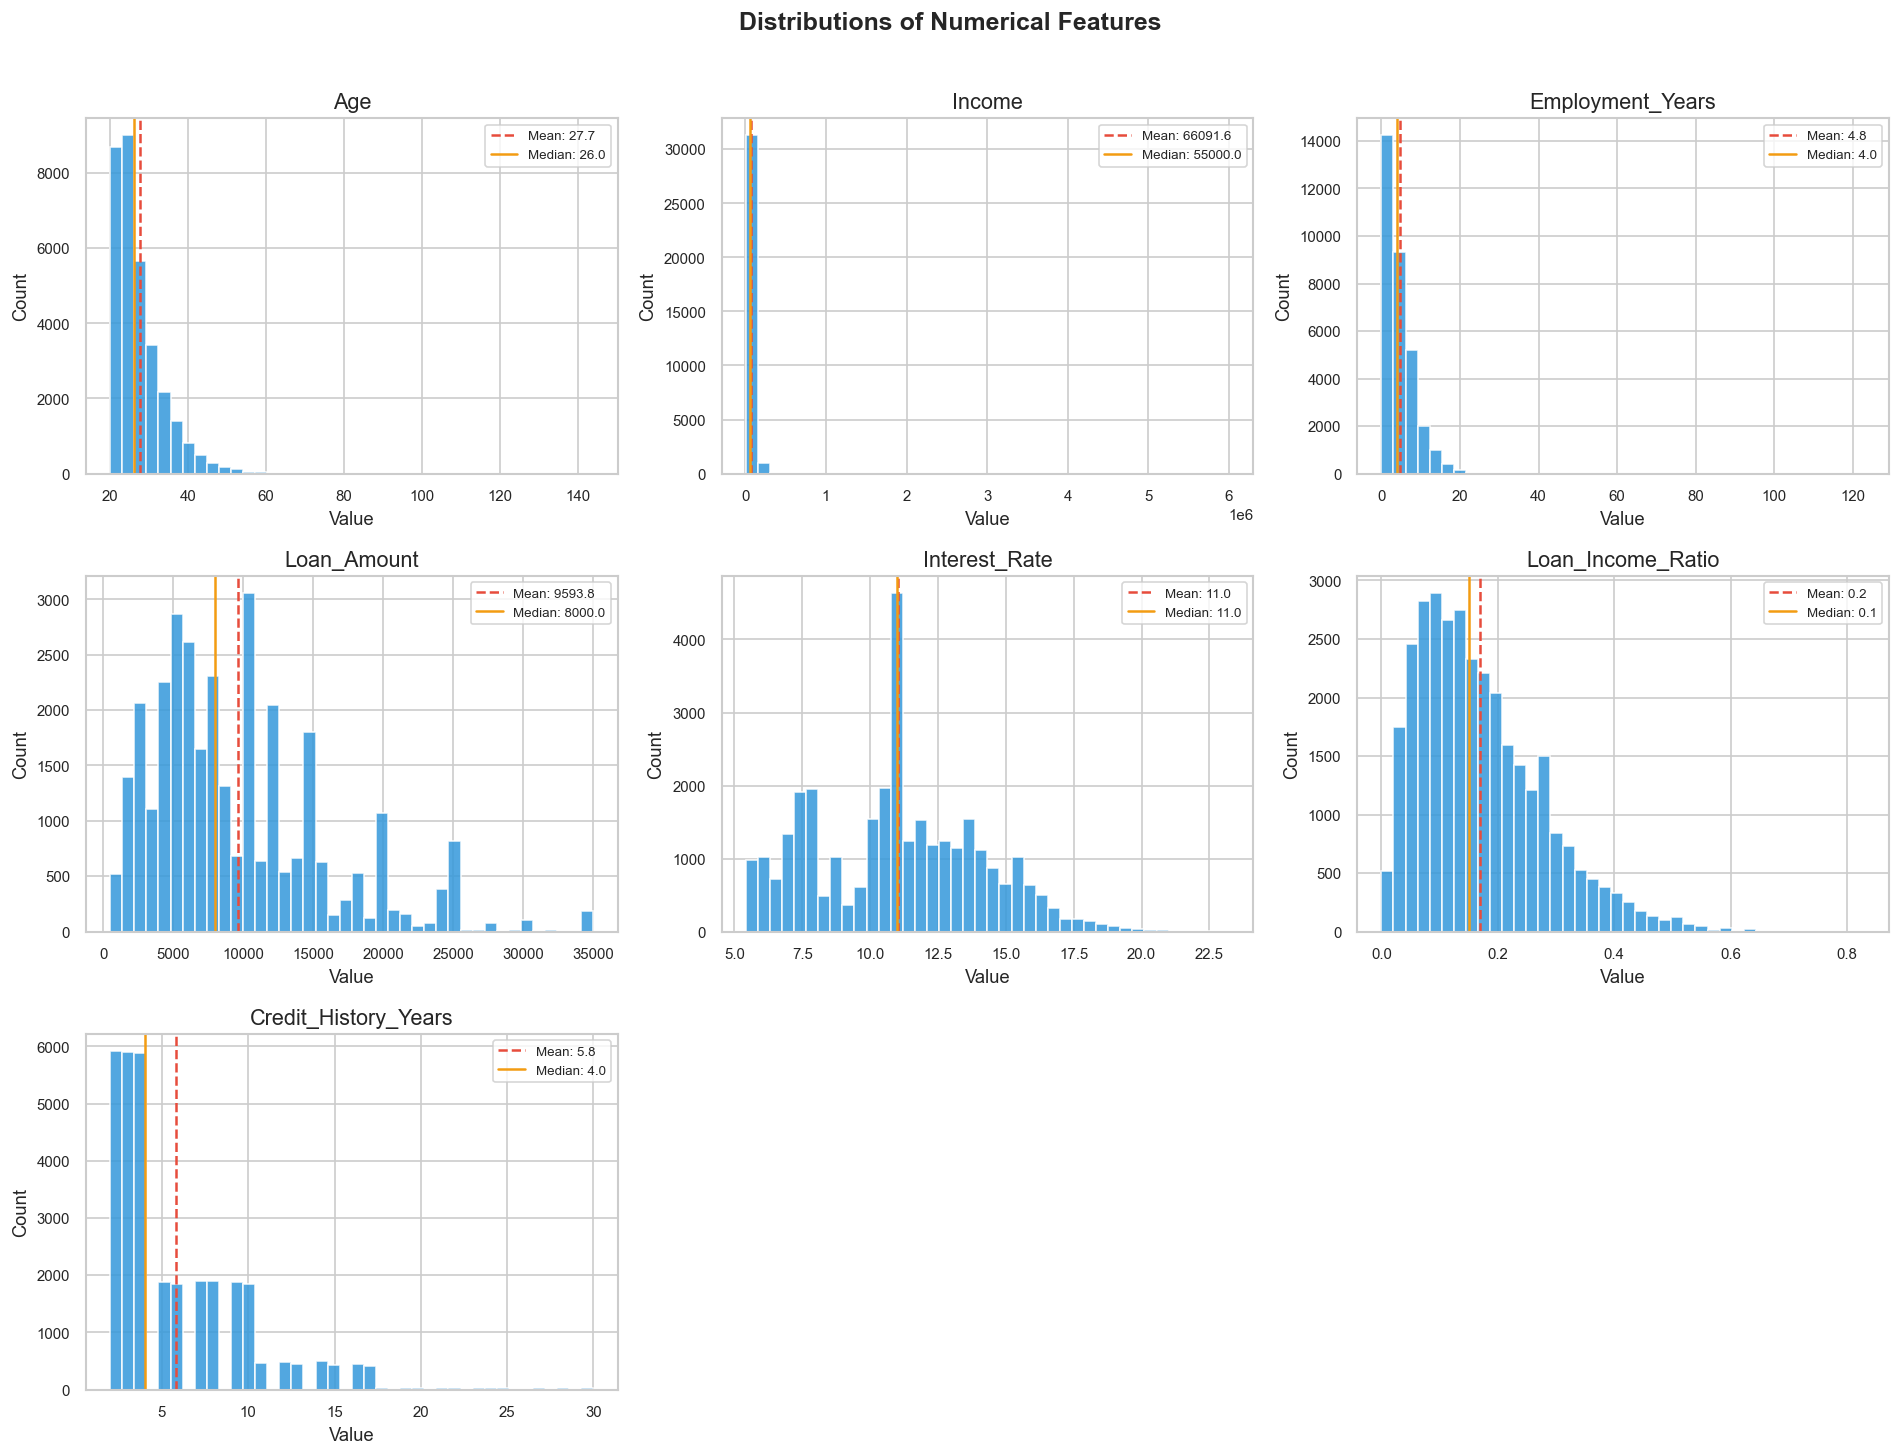

In [8]:
# ── Define numerical columns ───────────────────────────────────────────────
num_cols = ['Age', 'Income', 'Employment_Years', 'Loan_Amount',
            'Interest_Rate', 'Loan_Income_Ratio', 'Credit_History_Years']

# ── Descriptive statistics ─────────────────────────────────────────────────
print('── Descriptive Statistics (Numerical Features) ──')
display(df[num_cols].describe().round(2))

# ── Distribution histograms ────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = df[col]
    ax.hist(data, bins=40, color='#3498db', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='#e74c3c', linewidth=1.5,
               linestyle='--', label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='#f39c12', linewidth=1.5,
               linestyle='-', label=f'Median: {data.median():.1f}')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

# Hide unused subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions of Numerical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The **red dashed line** = Mean. The **orange solid line** = Median.

- When the **mean > median**, the distribution is **right-skewed** (pulled right by high values)
- When they are close together, the distribution is approximately **symmetric**


* **AGE** :The age distribution indicates that most borrowers are young adults, with a median age of 26 years. However, the maximum age value of 144 suggests the presence of unrealistic outliers or possible data entry errors that may require treatment during preprocessing.

* **INCOME** :Income shows a positively skewed distribution, as evidenced by the mean income being higher than the median income. This suggests the presence of high-income outliers, with a maximum income of 6,000,000 significantly exceeding the upper quartile value.

* **EMPLOYMENT_YEARS** :Employment duration appears moderately right-skewed, with most borrowers having fewer than 7 years of employment experience. The maximum value of 123 years is unrealistic and indicates potential anomalies within the dataset.

* **LOAN_AMOUNT** :Loan amounts are moderately concentrated around the median value of 8,000, although the distribution exhibits slight positive skewness due to larger loan values among a smaller subset of borrowers.

* **INTREST_RATE** :Interest rates appear relatively symmetrically distributed, as indicated by the close proximity between the mean and median values.

* **LOAN_INCOME_RATIO**:The loan-to-income ratio demonstrates positive skewness, indicating that while most borrowers maintain manageable debt levels relative to income, a subset of borrowers exhibit substantially higher financial burden.

* **CREDIT_HISTORY_YEARS**:Credit history length is positively skewed, suggesting that the majority of borrowers possess relatively short credit histories, while fewer borrowers maintain long-term credit records.

#### Overall, the numerical variables exhibit varying degrees of positive skewness, particularly income, employment years, and loan-to-income ratio. Several variables also contain extreme outliers and unrealistic maximum values, indicating the need for data preprocessing and outlier treatment prior to model development.

## 5. Univariate Analysis(Categorical Features) <a id='4'></a>


── Home_Ownership ──


,Count,Percentage (%)
Home_Ownership,,
RENT,16378,50.5
MORTGAGE,13369,41.2
OWN,2563,7.9
OTHER,106,0.3



── Loan_Purpose ──


,Count,Percentage (%)
Loan_Purpose,,
EDUCATION,6411,19.8
MEDICAL,6042,18.6
VENTURE,5682,17.5
PERSONAL,5498,17.0
DEBT CONSOLIDATION,5189,16.0
HOME IMPROVEMENT,3594,11.1



── Loan_Risk_Grade ──


,Count,Percentage (%)
Loan_Risk_Grade,,
A,10703,33.0
B,10387,32.0
C,6438,19.9
D,3620,11.2
E,963,3.0
F,241,0.7
G,64,0.2



── Previous_Default ──


,Count,Percentage (%)
Previous_Default,,
No,26686,82.3
Yes,5730,17.7


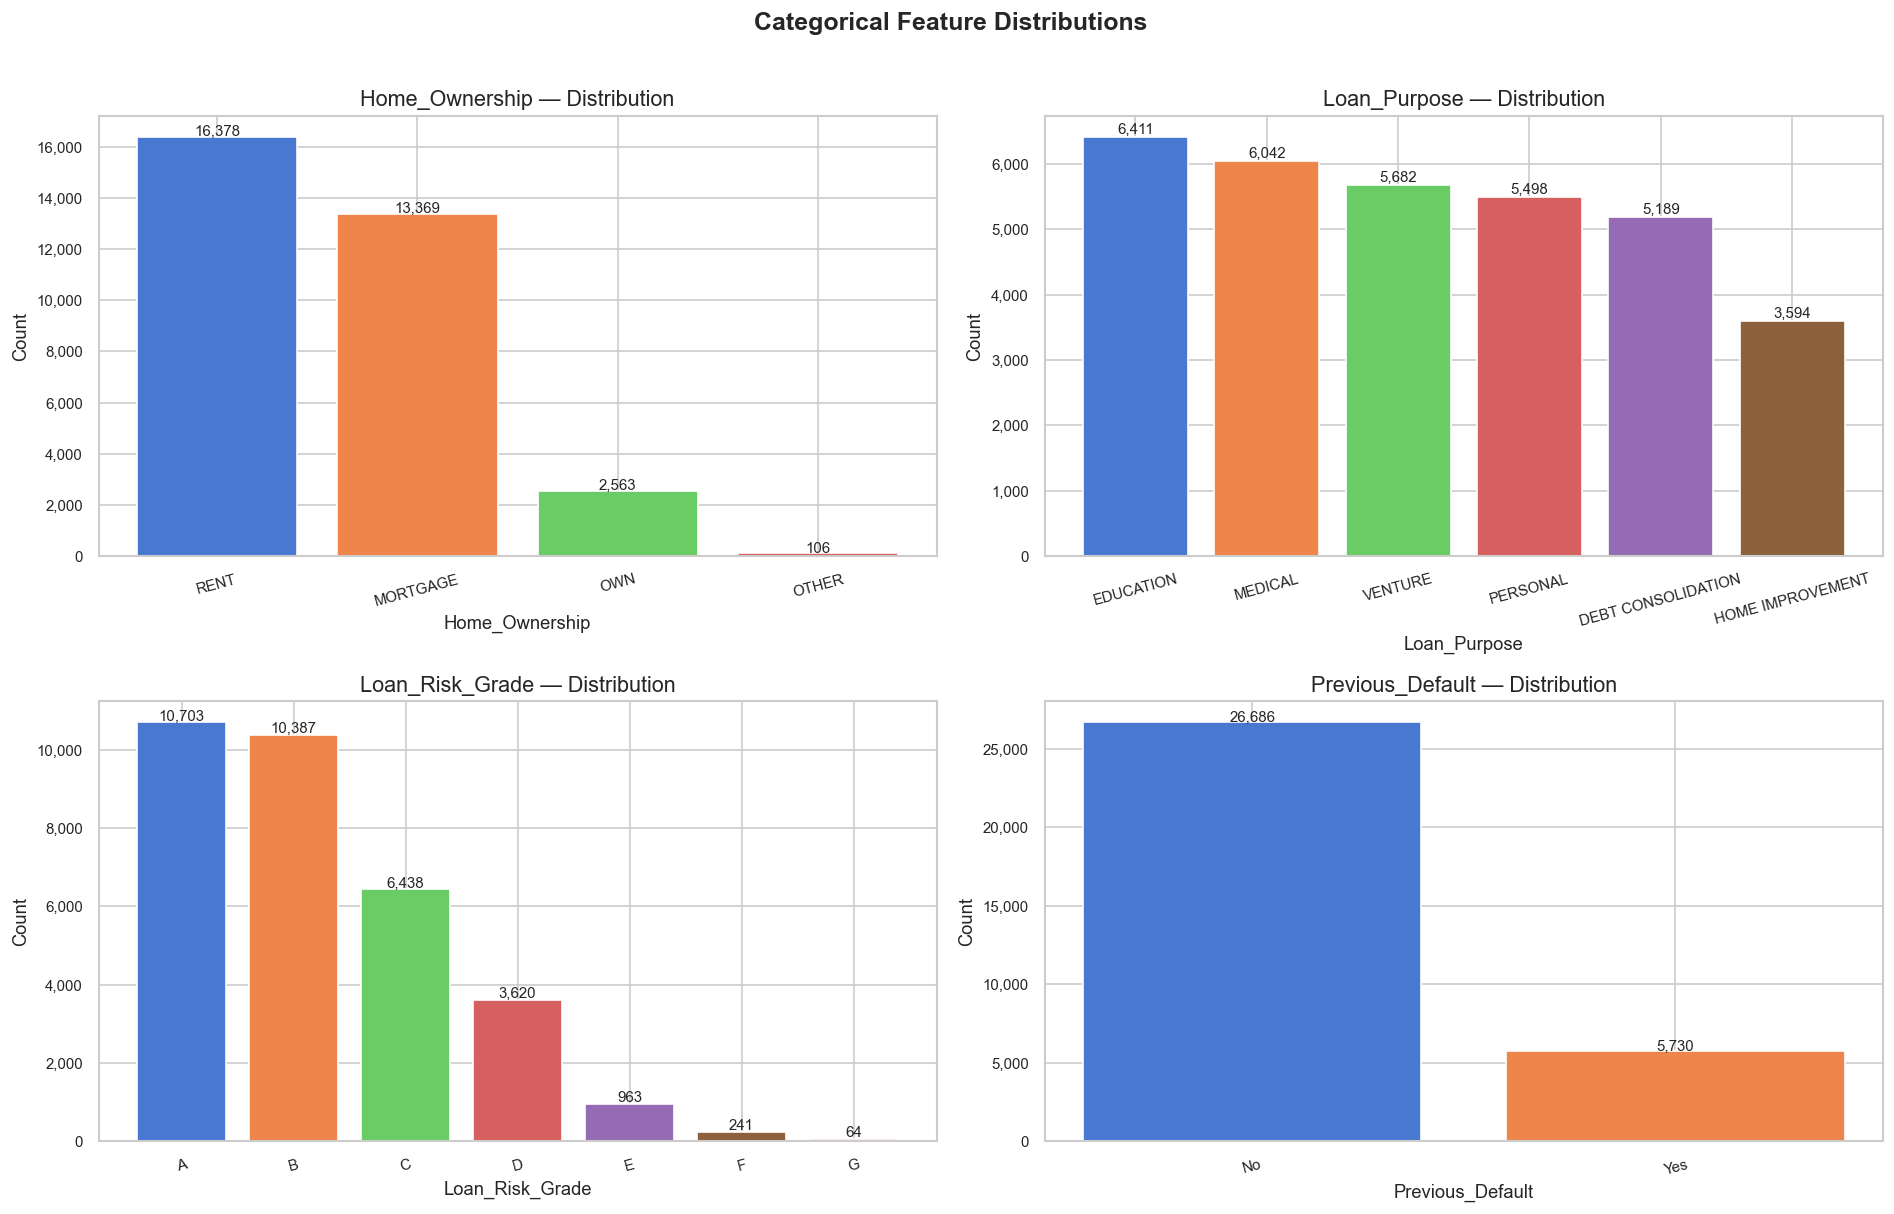

In [9]:
# ── Define categorical columns ─────────────────────────────────────────────
cat_cols = ['Home_Ownership', 'Loan_Purpose', 'Loan_Risk_Grade', 'Previous_Default']

# ── Print value counts ─────────────────────────────────────────────────────
for col in cat_cols:
    print(f'── {col} ──')
    vc = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    display(pd.DataFrame({'Count': vc, 'Percentage (%)': pct.round(1)}))
    print()

# ── Bar charts ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
palette = sns.color_palette('muted', 8)

for i, col in enumerate(cat_cols):
    ax = axes[i]
    order = df[col].value_counts().index
    counts = df[col].value_counts().values
    bars = ax.bar(order, counts, color=palette[:len(order)], edgecolor='white')
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}', ha='center', fontsize=9)
    ax.set_title(f'{col} — Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Categorical Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

* **Home_Ownership** :The majority of borrowers are either renting their homes (50.5%) or paying mortgages (41.2%), while only a small proportion fully own their homes (7.9%). This suggests that most applicants carry ongoing housing-related financial obligations, which may influence their repayment capacity and overall credit risk.

*  **Loan_Purpose** :Loan purposes are relatively well distributed across categories, with education and medical loans being the most common. This indicates that borrowers seek credit for diverse financial needs rather than a single dominant borrowing purpose.

* **Loan_Risk_Grade** :Most borrowers fall within the lower-risk grades A and B, accounting for approximately 65% of all loans. Higher-risk grades such as E, F, and G represent a very small portion of the dataset, suggesting that the lending institution is relatively conservative in issuing high-risk loans.

* **Previous_Default** :A large majority of borrowers (82.3%) have no history of previous default, while 17.7% have previously defaulted on credit obligations. Since prior repayment behavior is often a strong indicator of future financial reliability, this variable may significantly influence loan default prediction.

##### The categorical variables shows real and meaningful distributions consistent with consumer borrowing behavior. Most borrowers are renters or mortgage holders, loan purposes are diversified across financial needs, and the majority of borrowers belong to lower-risk credit grades. Additionally, most applicants have no prior default history, though a notable minority have previously defaulted, which may contribute significantly to predictive modeling.

## 6. Correlation Analysis

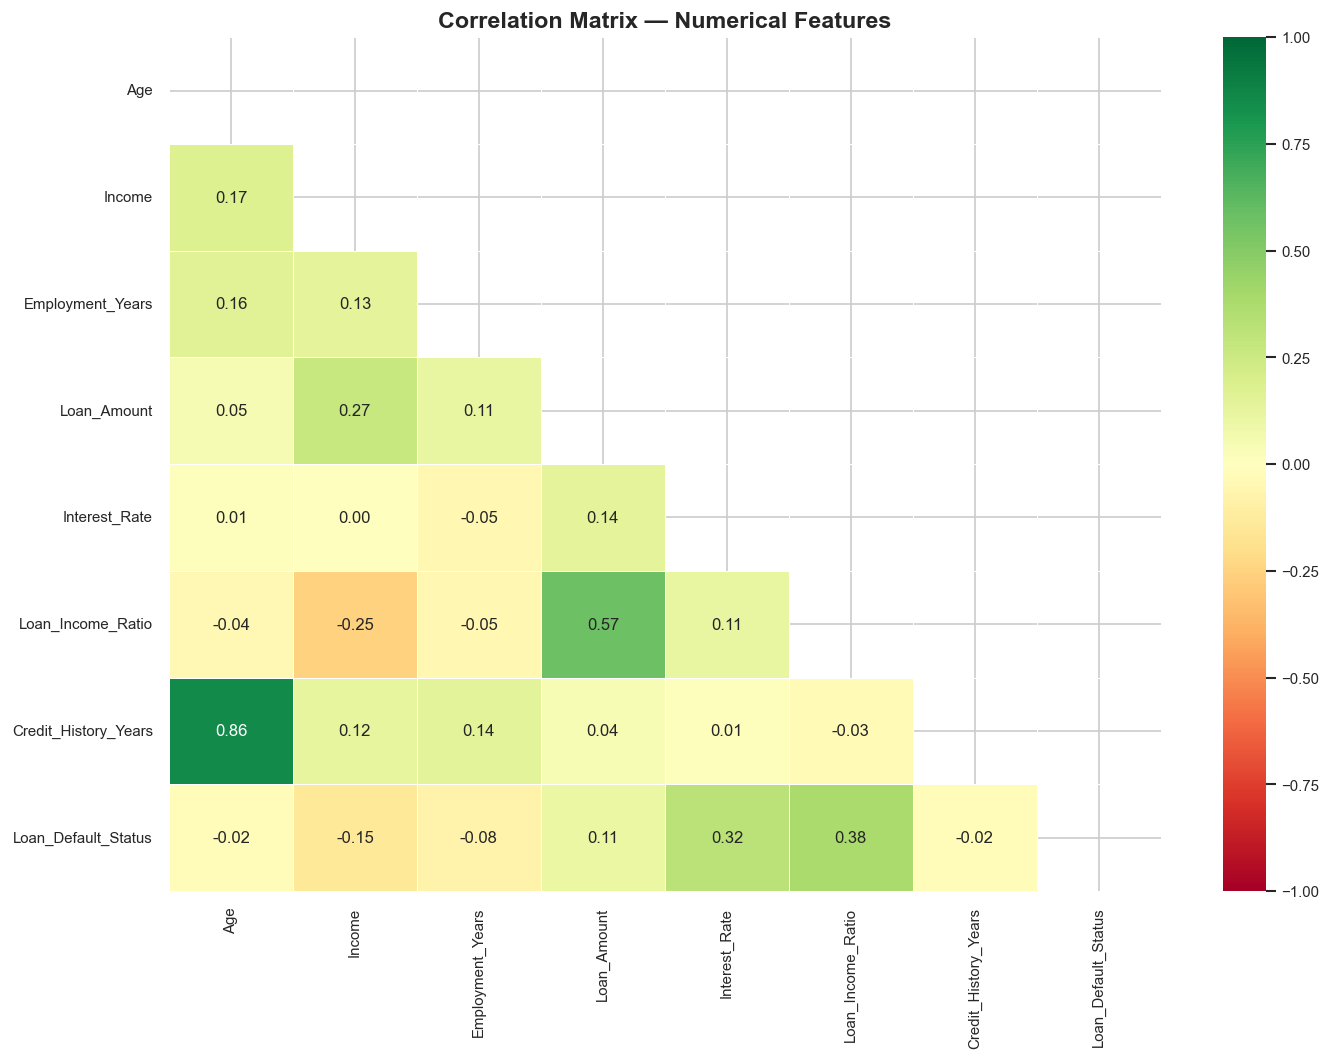

── Correlation with Target (Loan_Default_Status) ──


,Correlation
Income,-0.145005
Employment_Years,-0.082517
Age,-0.022698
Credit_History_Years,-0.016498
Loan_Amount,0.105736
Interest_Rate,0.320081
Loan_Income_Ratio,0.379697


In [10]:
# ── Compute correlation matrix ─────────────────────────────────────────────
num_all = num_cols + ['Loan_Default_Status']
corr_matrix = df[num_all].corr()

# ── Heatmap ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Correlations with target only ──────────────────────────────────────────
print('── Correlation with Target (Loan_Default_Status) ──')
target_corr = corr_matrix['Loan_Default_Status'].drop('Loan_Default_Status').sort_values()
display(target_corr.to_frame('Correlation').style.background_gradient(cmap='RdYlGn', vmin=-1, vmax=1))

* **Loan_Income_Ratio** (0.380):
Borrowers taking loans that are large relative to their income are much more likely to default.
* **Interest_Rate** (0.320):
Borrowers with higher interest rates tend to default more frequently.
* **Income (-0.145)**:
Higher income slightly lowers default probability, but income alone is not a strong predictor.
* **Employment_Years (-0.083)**:
Longer employment history may indicate financial stability, but the effect is weak.
* **Age & Credit_History_Year**:
These variables do not show meaningful linear relationships with default risk in this dataset.

Correlation analysis revealed that Loan_Income_Ratio (0.38) and Interest_Rate (0.32) exhibited the strongest positive relationships with loan default status, suggesting that borrowers with higher repayment burdens and higher interest rates are more likely to default.

Income and Employment_Years showed weak negative correlations with default, indicating that higher income levels and longer employment duration may slightly reduce default risk.

Age and Credit_History_Years displayed negligible correlations with the target variable, suggesting limited linear influence on default behavior within this dataset.

## 7. Bivariate Analysis (Features vs Target)

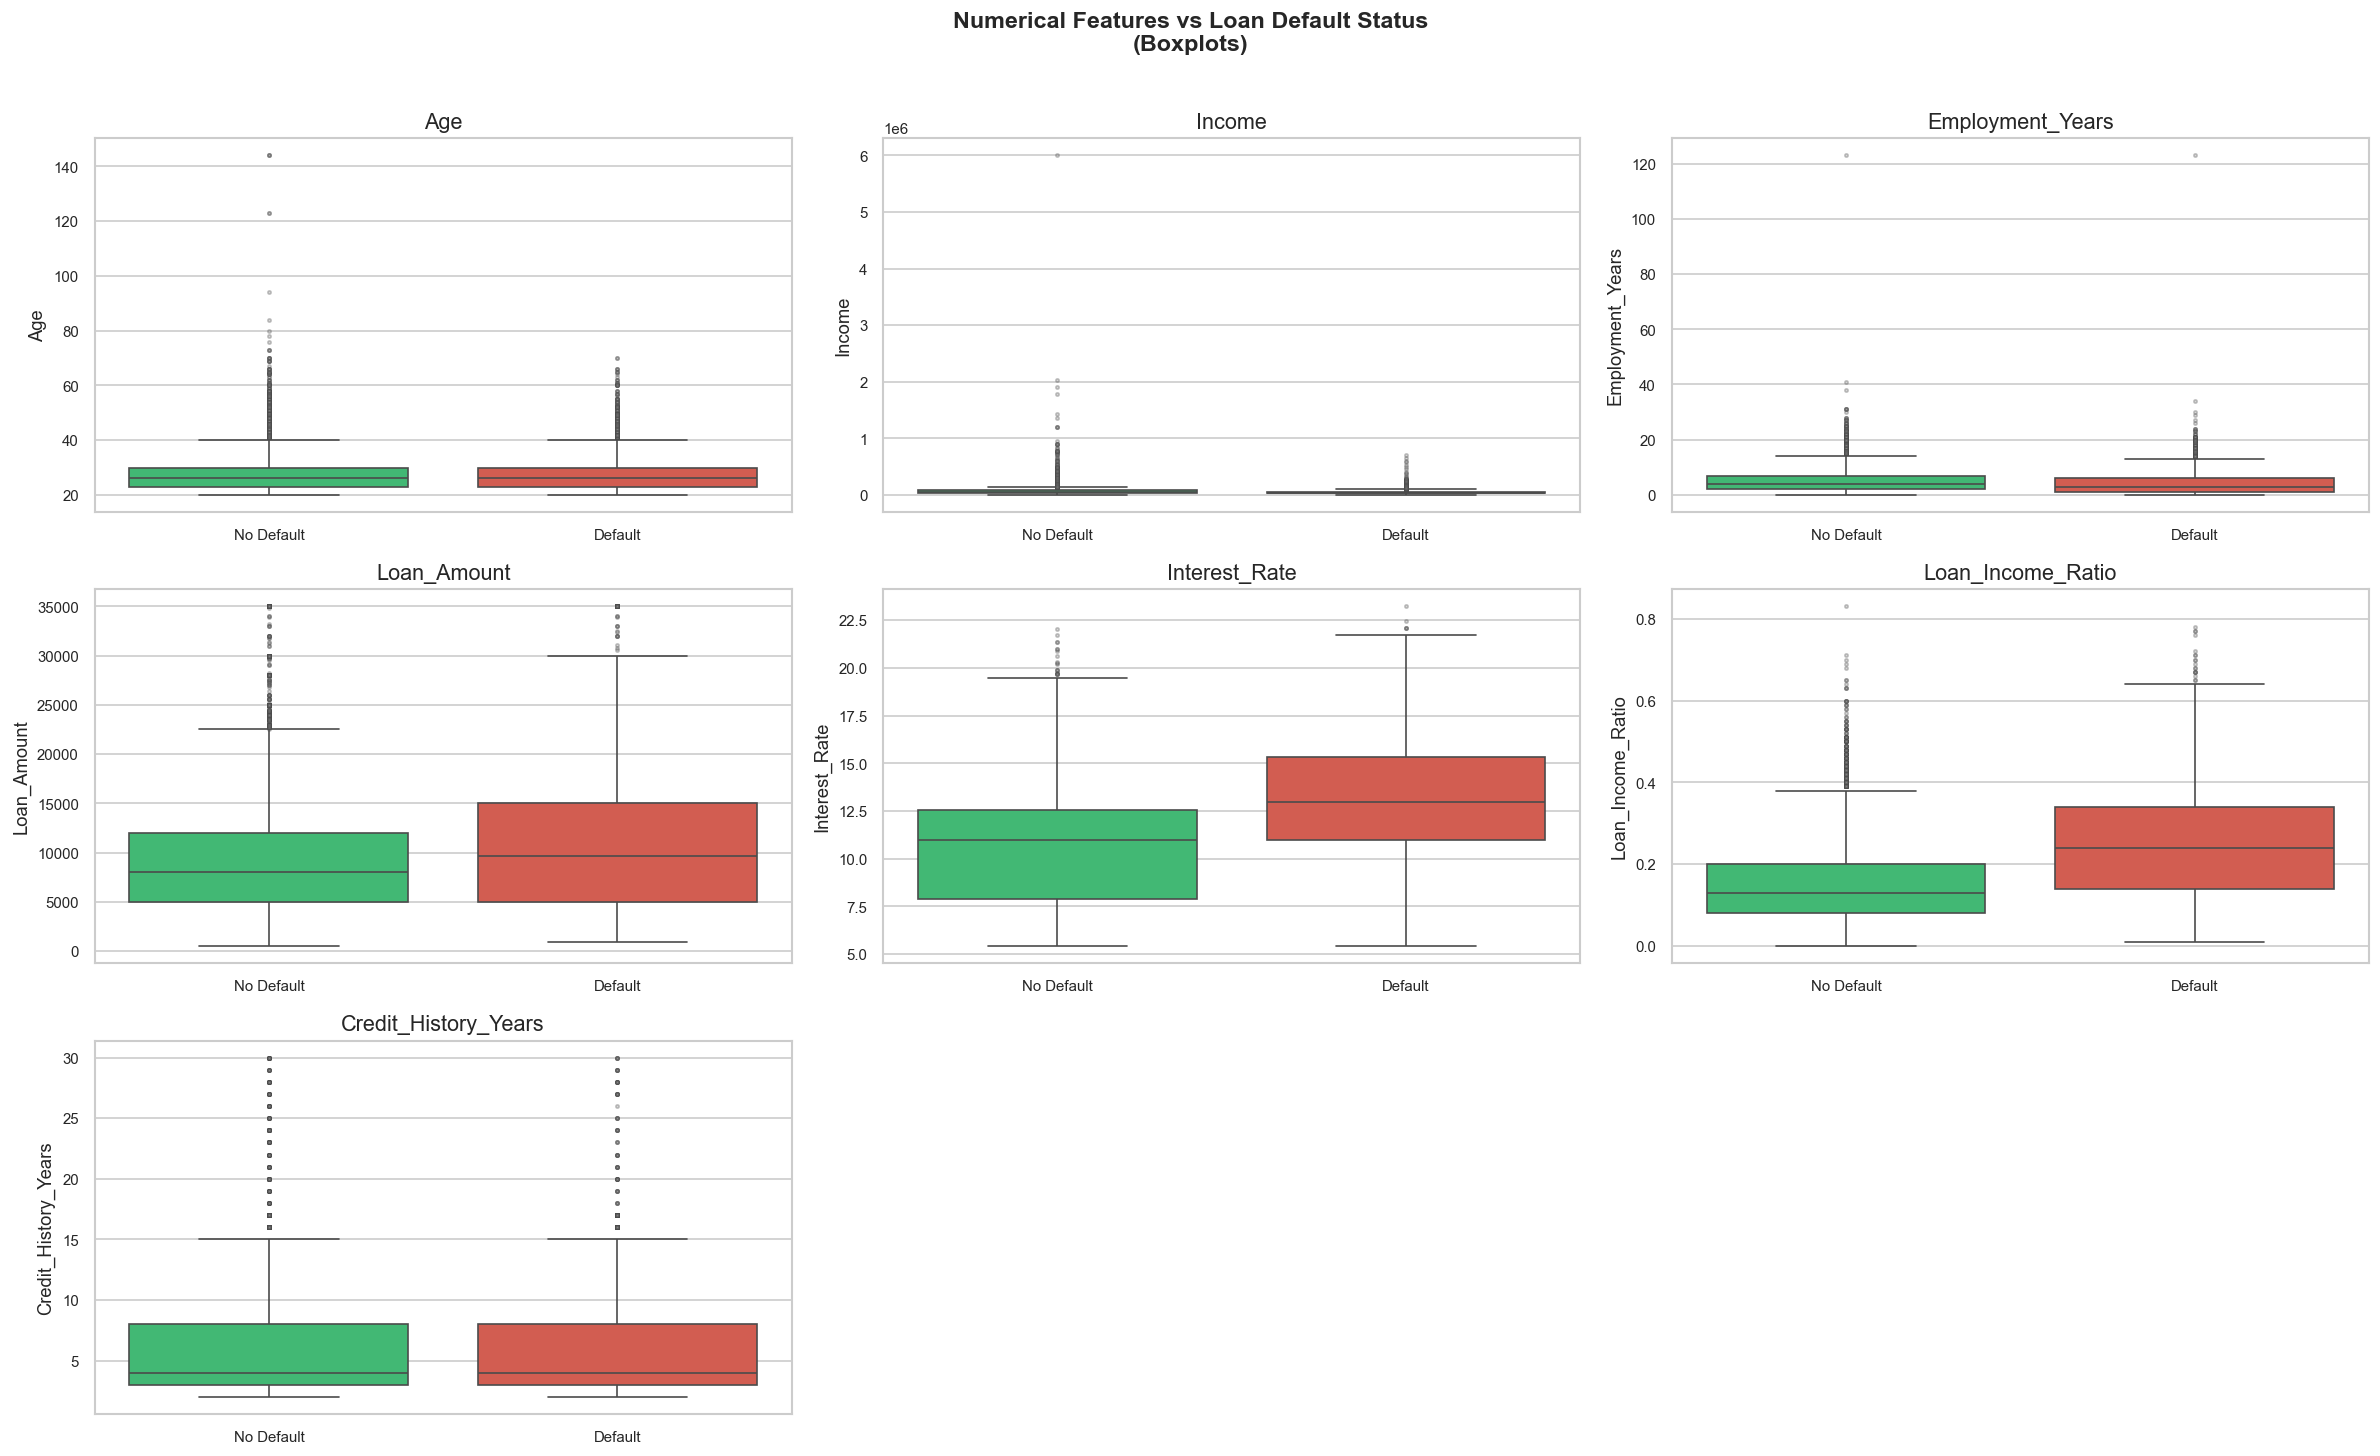

In [11]:
# ── PART A: Numerical features — boxplots by target ────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(20, 12))
axes = axes.flatten()
target_labels = {0: 'No Default', 1: 'Default'}
plot_df = df.copy()
plot_df['Status'] = plot_df['Loan_Default_Status'].map(target_labels)

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.boxplot(data=plot_df, x='Status', y=col,
                palette={'No Default': '#2ecc71', 'Default': '#e74c3c'},
                order=['No Default', 'Default'], ax=ax,
                flierprops=dict(marker='o', markerfacecolor='grey',
                                markersize=2, alpha=0.3))
    ax.set_title(col)
    ax.set_xlabel('')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features vs Loan Default Status\n(Boxplots)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

* **Income vs Loan_Default_Status**:
The boxplot indicates that borrowers who defaulted generally have lower median incomes compared to non-defaulters. This suggests that lower-income borrowers may face greater difficulty meeting repayment obligations.

* **Employment_Years vs Default**
Borrowers with longer employment duration appear slightly less likely to default, suggesting that employment stability may contribute to repayment reliability.

However, the substantial overlap between the groups indicates that employment years alone may not strongly distinguish defaulters from non-defaulters.

* **Age vs Default** :
The distribution of age appears relatively similar across both default categories, suggesting that age has limited influence on default behavior within this dataset.

* **Credit_History_Years vs Default**:
Credit history heavily overlaps which shows minimal variation between defaulters and non-defaulters, indicating a weak relationship with loan default status.

* **Loan_Amount vs Default**:
Defaulted borrowers tend to exhibit slightly higher loan amounts, implying that larger loan obligations may increase repayment risk.

The presence of several extreme loan amount outliers suggests that a small number of borrowers received significantly larger loans than the majority population.

* **Interest_Rate vs Default**:
The boxplot reveals that defaulters generally have higher interest rates compared to non-defaulters, indicating a positive association between borrowing cost and default risk.

This pattern may reflect risk-based pricing, where borrowers perceived as higher risk are assigned higher interest rates.

* **Loan_Income_Ratio vs Default**:
Borrowers who defaulted show noticeably higher loan-to-income ratios, suggesting that higher debt burdens relative to income significantly increase the likelihood of default.

The relatively distinct separation between the two groups indicates that Loan_Income_Ratio may serve as an important predictor of credit risk.

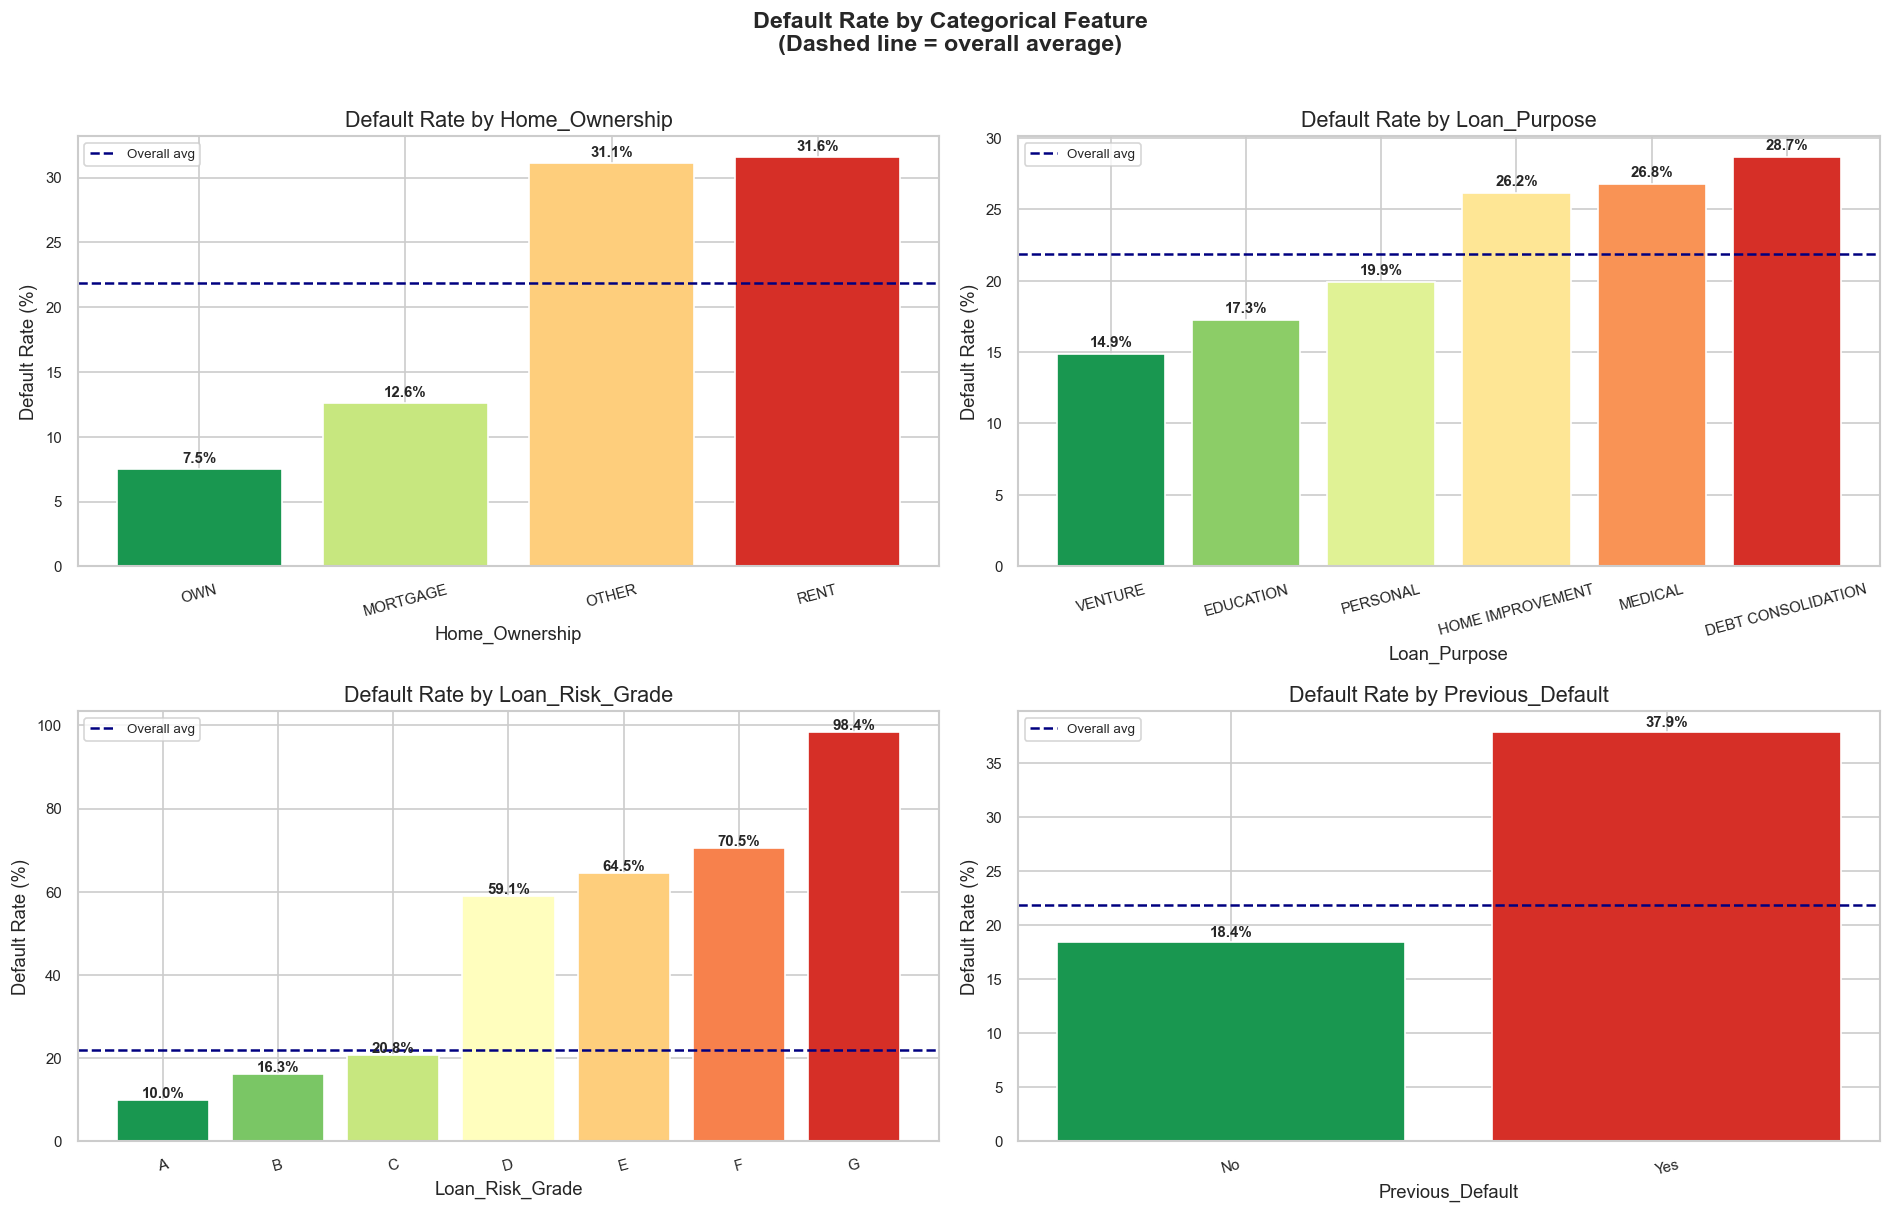

In [12]:
## PART B: Categorical features — default rate by category ───────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    default_rate = df.groupby(col)['Loan_Default_Status'].mean().sort_values() * 100
    colors_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(default_rate)))
    bars = ax.bar(default_rate.index, default_rate.values,
                  color=colors_bar, edgecolor='white')
    for bar, val in zip(bars, default_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.axhline(df['Loan_Default_Status'].mean() * 100, color='navy',
               linestyle='--', linewidth=1.5, label='Overall avg')
    ax.set_title(f'Default Rate by {col}')
    ax.set_ylabel('Default Rate (%)')
    ax.set_xlabel(col)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Default Rate by Categorical Feature\n(Dashed line = overall average)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

* **Home_Ownership vs Default**:
The analysis indicates that borrowers who rent their homes exhibit higher default rates compared to homeowners or borrowers with mortgages. This may suggest lower financial stability among renters.

Homeowners appear less likely to default, potentially reflecting greater financial security and asset ownership.”

* **Loan_Purpose vs Default**
Default rates vary across loan purposes, indicating that the reason for borrowing may influence repayment behavior.

Borrowers taking loans for debt consolidation(i.e to pay back debt) and medicals exhibit relatively higher default rates, possibly due to emergency or non-income-generating financial pressures.

Venture-related loans(i.e taking loans to fund their business) appear associated with lower default rates, which may reflect borrowers’ expectations of future income generation.”

* **Loan_Risk_Grade vs Default**:
Loan default rates increase progressively across lower credit risk grades, indicating that the grading system effectively differentiates high-risk borrowers from low-risk borrowers.

Borrowers assigned lower loan grades demonstrate substantially higher default frequencies, validating the predictive relevance of the institution’s risk grading.


* **Previous_Default vs Default**:
Borrowers with a history of previous default exhibit significantly higher current default rates compared to borrowers without prior default history.

This suggests that past repayment behavior is a strong indicator of future credit risk.

## 8. Outlier Investigation


── Outlier Summary (IQR Method) ──


,Lower Bound,Upper Bound,Outlier Count,Outlier %
Feature,,,,
Age,12.50,40.50,1491,4.60
Income,-22472.00,140232.00,1478,4.56
Employment_Years,-5.50,14.50,852,2.63
Loan_Amount,-5875.00,23125.00,1679,5.18
Interest_Rate,1.56,20.04,70,0.22
Loan_Income_Ratio,-0.12,0.44,650,2.01
Credit_History_Years,-4.50,15.50,1139,3.51


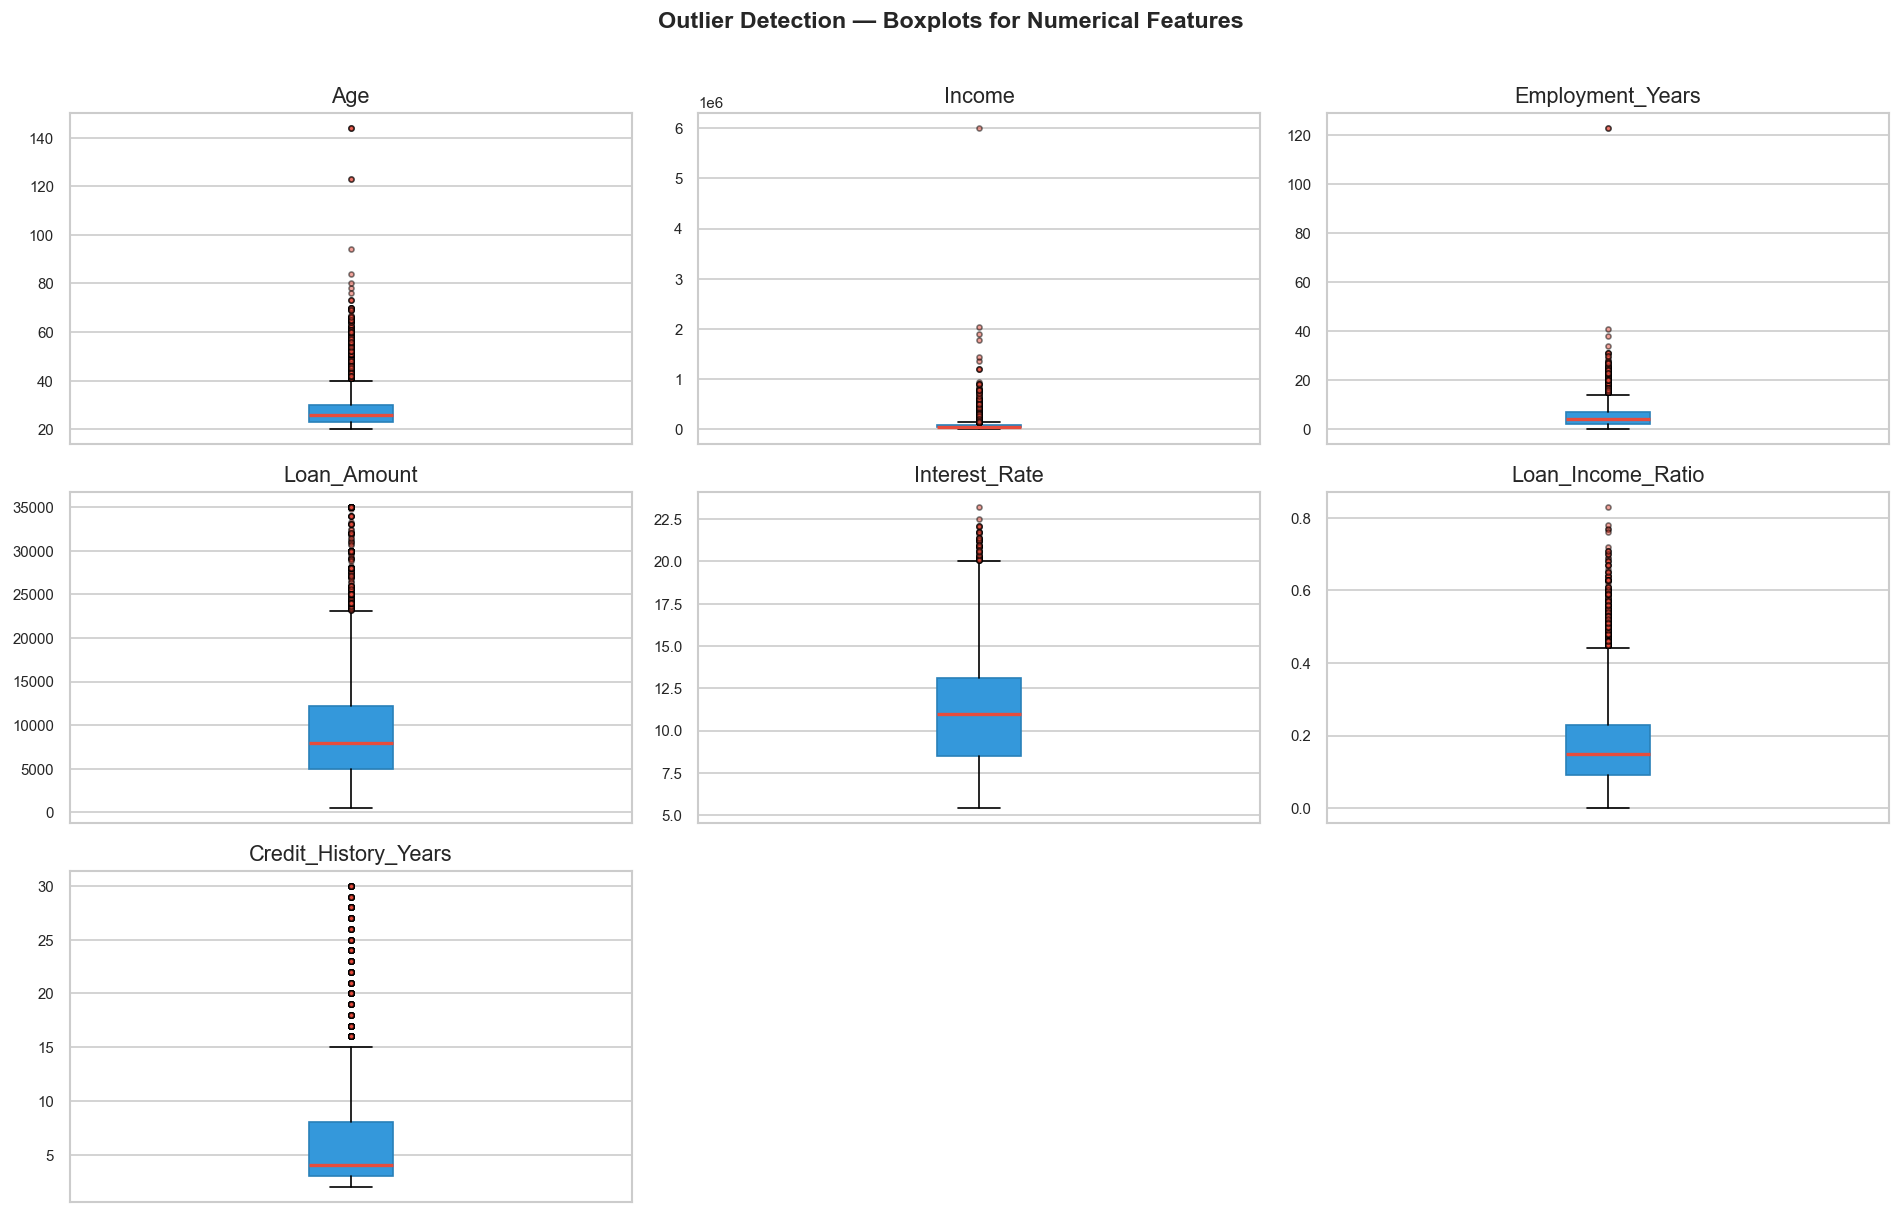

In [13]:
# ── IQR-based outlier counts ───────────────────────────────────────────────
outlier_summary = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_out = n_out / len(df) * 100
    outlier_summary.append({'Feature': col, 'Lower Bound': round(lower, 2),
                             'Upper Bound': round(upper, 2),
                             'Outlier Count': n_out,
                             'Outlier %': round(pct_out, 2)})

print('── Outlier Summary (IQR Method) ──')
display(pd.DataFrame(outlier_summary).set_index('Feature'))

# ── Boxplot grid ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#3498db', color='#2980b9'),
               medianprops=dict(color='#e74c3c', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='#e74c3c',
                               markersize=3, alpha=0.5))
    ax.set_title(col)
    ax.set_xticks([])

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection — Boxplots for Numerical Features',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Outliers were identified using the Interquartile Range (IQR) method, where observations falling below Q1 − 1.5(IQR) or above Q3 + 1.5(IQR) were considered outliers.

* **Age (4.60% outliers)**
Approximately 4.6% of observations in the Age variable were identified as outliers. This suggests the presence of older borrowers whose ages fall significantly outside the central distribution of the dataset.”

* **Income (4.56% outliers)**
Income contains high-value outliers, indicating the presence of a smaller group of significantly high-income borrowers compared to the general borrower population.

Such income variability is expected in financial datasets due to differences in earning capacity across borrowers.

* **Employment_Years (2.63%)**
A relatively small proportion of borrowers exhibited unusually long employment durations, potentially reflecting highly stable or experienced individuals within the credit population.

* **Loan_Amount (5.18%)**
Loan_Amount showed the highest proportion of outliers (5.18%), suggesting the presence of borrowers with exceptionally large loan requests relative to the majority population.

Business interpretation:
These extreme loan values may represent higher financial exposure for lenders and could potentially contribute to elevated credit risk.


* **Interest_Rate (0.22%)**
Interest_Rate displayed very few outliers, indicating that lending rates are relatively consistent across borrowers, with limited extreme variations.


* **Loan_Income_Ratio (2.01%)**
A small proportion of borrowers exhibited unusually high loan-to-income ratios, suggesting elevated debt burdens relative to income and potentially higher repayment vulnerability.

That’s a very meaningful business insight.

* **Credit_History_Years (3.51%)**
Outliers in Credit_History_Years indicate the presence of borrowers with significantly longer credit histories compared to the majority of applicants.



Since financial datasets naturally contain extreme borrower profiles, the identified outliers were not immediately treated as errors. Their business relevance was considered before deciding on any preprocessing strategy.

Outlier analysis using the IQR method revealed moderate levels of outliers across several financial variables. Loan_Amount and Age exhibited the highest proportions of outliers, while Interest_Rate showed minimal extreme variation. The detected outliers likely represent genuine borrower behavior, such as high-income earners or borrowers requesting unusually large loans, rather than data quality issues. Given the nature of financial data, these extreme observations may contain valuable information for identifying credit risk and were therefore carefully evaluated before preprocessing decisions.

## 9. EDA Summary & Key Findings



### 1. Dataset Structure
- **32,416 rows** and **12 columns** — a well-sized dataset for credit risk modelling
- **7 numerical features**, **4 categorical features**, **1 binary target**
-  No missing values — the dataset is clean and ready for feature engineering

---

### 2. Class Imbalance
- **78.1% No Default** vs **21.9% Default** — a roughly **3.6:1 ratio**
- This is a **moderately imbalanced** dataset
---

### 3. Strongest Predictors (Correlation with Target)
| Feature | Correlation | Interpretation |
|---------|-------------|----------------|
| `Loan_Income_Ratio` | **+0.38** | Higher ratio = higher default risk |
| `Interest_Rate` | **+0.32** | Higher rate = riskier borrower |
| `Loan_Amount` | +0.11 | Larger loans slightly riskier |
| `Income` | **−0.15** | Higher income = lower default risk |
| `Employment_Years` | −0.08 | Longer employment = slightly lower risk |
| `Loan_Risk_Grade` | N/A (categorical) | **Strongest overall predictor** (Grade G = 98.4% default rate!) |
| `Previous_Default` | N/A (categorical) | Strong predictor  past behaviour predicts future behaviour |

---

### 4. Key Outlier Findings
- `Age` has a **maximum of 144** — this is an impossible value (data entry error)
- `Income` reaches **6,000,000** — extremely high but possible (high-net-worth individuals)
- `Loan_Amount` has extreme outliers on the high end.

---

### 5. Categorical Insights
- **Loan_Risk_Grade** is a powerful ordinal feature — default rates escalate from ~10% (Grade A) to ~98% (Grade G)
- **Previous_Default = Yes** borrowers have dramatically higher default rates
- **Home_Ownership = OTHER** has a higher default rate than RENT/OWN/MORTGAGE
- **Loan_Purpose** shows some variation, DEBT CONSOLIDATION and MEDICAL tend to have higher default rates than EDUCATION

---
